# Notebook 02: Basic Exploratory Data Analysis

This notebook performs initial descriptive analysis of the DBLP subset:

1. **Papers per Year** — publication count time series and growth trends
2. **Top Authors** — most prolific researchers and productivity distribution
3. **Co-Author Network** — basic collaboration graph and statistics
4. **Most Common Keywords** — title-based keyword and bigram analysis


In [1]:
import sys, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Project root
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\Rekrutacja_nokia


In [2]:
# Load processed data
from src.parser import load_from_parquet

df = load_from_parquet(PROJECT_ROOT / "data" / "processed" / "dblp_subset.parquet")
print(f"Loaded {len(df):,} records")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
df.head(3)

Loaded 8,462,457 records
Year range: 1936 - 2026


,title,authors,year,venue,pub_type,venue_category,key
0,Curvedness.,[],2014,"Computer Vision, A Reference Guide",incollection,other,reference/vision/X14bd
1,Transparency and Translucency.,[Manish Singh 0001],2014,"Computer Vision, A Reference Guide",incollection,other,reference/vision/Singh14
2,Surface Orientation Histogram (Discrete Versio...,[],2014,"Computer Vision, A Reference Guide",incollection,other,reference/vision/X14ii



## 2.1 Papers per Year

- How has the volume of CS publications changed over time? 
- Average growth.
- Is the growth exponential?
- and so on...


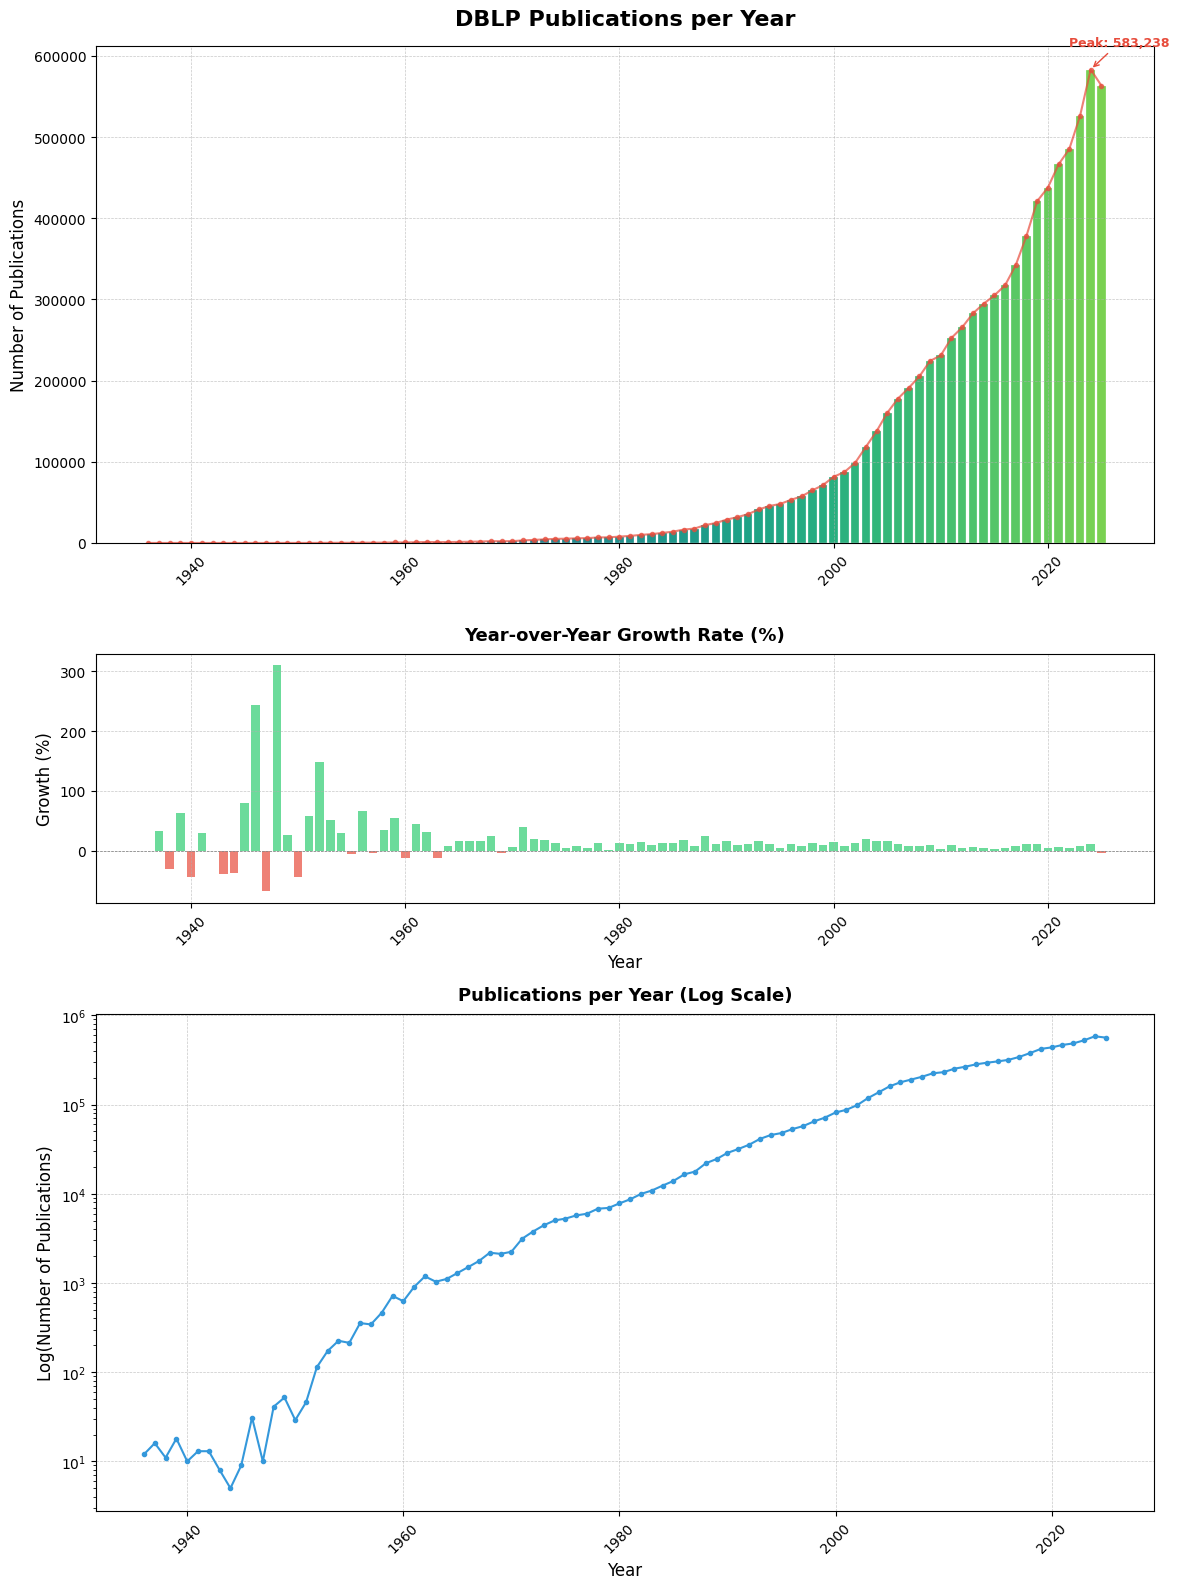


Summary Statistics:
Total papers: 8,321,302
Avg papers/year: 92,459
Peak year: 2024 (583,238 papers)
Avg YoY growth: 18.9%
Avg YoY growth (>2000): 8.1%


In [12]:
# Count papers per year
papers_per_year = df.groupby('year').size().reset_index(name='count')
papers_per_year = papers_per_year.sort_values('year')

papers_per_year = papers_per_year.drop(papers_per_year["year"].idxmax())

# Compute year-over-year growth
papers_per_year['yoy_growth'] = papers_per_year['count'].pct_change() * 100

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(12, 16),
    gridspec_kw={'height_ratios': [2, 1, 2]}
)

# Publication count
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(papers_per_year)))
ax1.bar(papers_per_year['year'], papers_per_year['count'], color=colors, edgecolor='white', linewidth=0.2)
ax1.plot(papers_per_year['year'], papers_per_year['count'], 'o-', color='#e74c3c', markersize=3, linewidth=1.5, alpha=0.7)
ax1.set_title('DBLP Publications per Year', fontsize=16, fontweight='bold', pad=15)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_ylabel('Number of Publications', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Annotate notable points
max_year = papers_per_year.loc[papers_per_year['count'].idxmax()]
ax1.annotate(f'Peak: {int(max_year["count"]):,}',
             xy=(max_year['year'], max_year['count']),
             xytext=(max_year['year']-2, max_year['count']*1.05),
             fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#e74c3c'),
             color='#e74c3c')

# Growth rate
growth_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in papers_per_year['yoy_growth'].fillna(0)]
ax2.bar(papers_per_year['year'], papers_per_year['yoy_growth'].fillna(0), color=growth_colors, alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax2.set_title('Year-over-Year Growth Rate (%)', fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Growth (%)', fontsize=12)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_xlabel('Year', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

ax3.plot(papers_per_year['year'], papers_per_year['count'], 'o-', color='#3498db', markersize=3)
ax3.set_yscale('log')
ax3.set_title('Publications per Year (Log Scale)', fontsize=13, fontweight='bold', pad=10)
ax3.set_ylabel('Log(Number of Publications)', fontsize=12)
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax3.set_xlabel('Year', fontsize=12)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'papers_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary Statistics:")
print(f"Total papers: {papers_per_year['count'].sum():,}")
print(f"Avg papers/year: {papers_per_year['count'].mean():,.0f}")
print(f"Peak year: {int(max_year['year'])} ({int(max_year['count']):,} papers)")
print(f"Avg YoY growth: {papers_per_year['yoy_growth'].mean():.1f}%")
print(f"Avg YoY growth (>2000): {papers_per_year['yoy_growth'].where(papers_per_year['year']>2000).mean():.1f}%")

here has been an exponential growth of scientific computer science publications over the years as shown on the log scale plot. The DBLP dataset contains over 8.3 million papers, with an average of about 92 thousand publications per year. The peak output occurs in 2024 with more than 583 thousand papers, highlighting the rapid expansion of research activity in recent years.

Year over year growth has been strong overall, averaging 18.9 percent across the full timeline. However, when focusing on the period after 2000, the average growth stabilizes at around 8.1 percent, suggesting a transition from early rapid expansion to more steady and sustained growth. This pattern indicates that while the field continues to grow, it is maturing with more consistent publication rates over time. The slight decline observed in 2025, the first such drop since 1970, may suggest that the field is beginning to approach a plateau, though additional data would be needed to confirm whether this marks a lasting shift or a temporary fluctuation.

---

## 2.2 Venue Types

What types of venues are the most popular? How has the trend changed over the years?

In [3]:
print("=== Publication Types ===")
type_counts = df['pub_type'].value_counts()
for ptype, count in type_counts.items():
    print(f"  {ptype:20s}: {count:>10,} ({count/len(df)*100:.1f}%)")

print(f"\n=== Venue Category ===")
cat_counts = df['venue_category'].value_counts()
for cat, count in cat_counts.items():
    print(f"  {cat:20s}: {count:>10,} ({count/len(df)*100:.1f}%)")

=== Publication Types ===
  article             :  4,280,730 (50.6%)
  inproceedings       :  3,872,430 (45.8%)
  phdthesis           :    152,755 (1.8%)
  incollection        :     71,095 (0.8%)
  proceedings         :     64,044 (0.8%)
  book                :     21,376 (0.3%)
  mastersthesis       :         27 (0.0%)

=== Venue Category ===
  journal             :  4,280,730 (50.6%)
  conference          :  3,936,474 (46.5%)
  other               :    245,253 (2.9%)


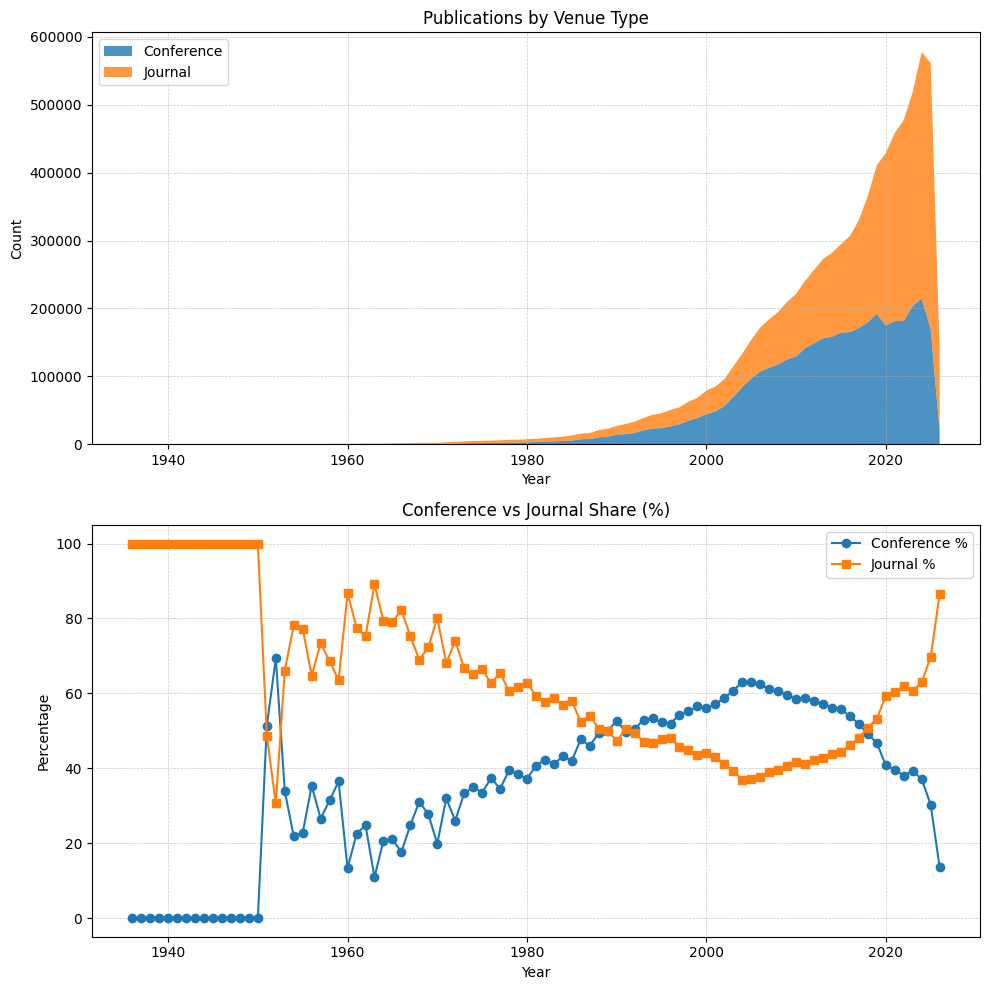

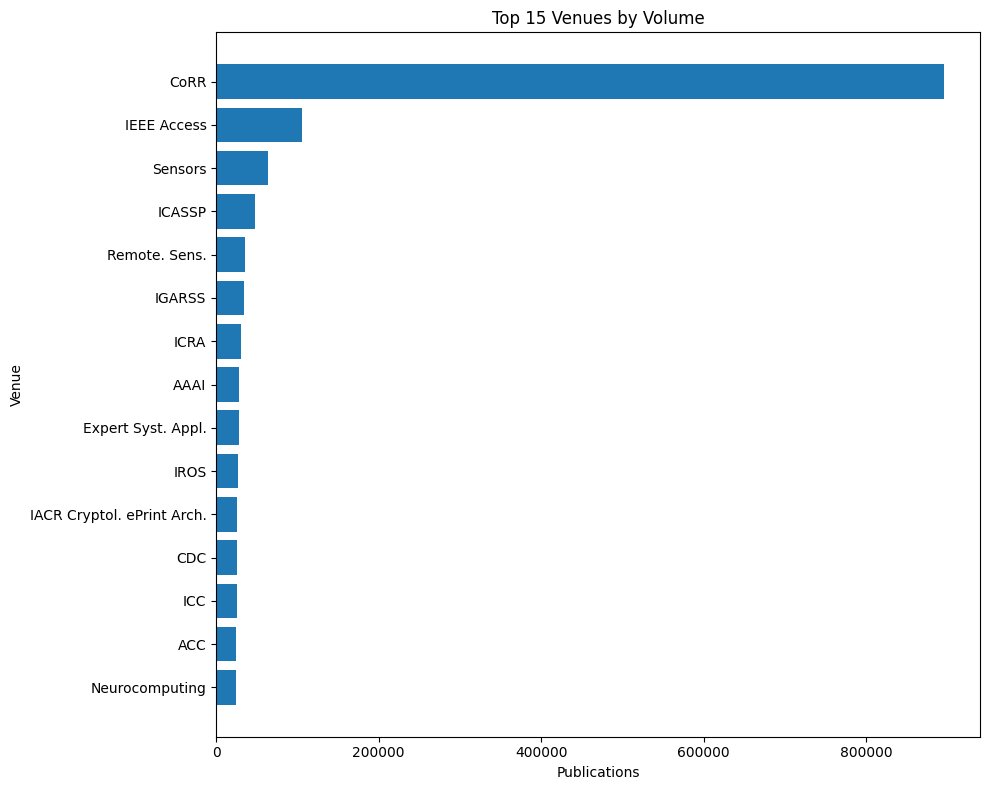

In [23]:

# filtrujemy tylko conference i journal
df_filtered = df[df["venue_category"].isin(["conference", "journal"])].copy()

# liczba publikacji per rok i typ
yearly_counts = (
    df_filtered
    .groupby(["year", "venue_category"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# upewniamy się że obie kolumny istnieją
for col in ["conference", "journal"]:
    if col not in yearly_counts:
        yearly_counts[col] = 0

# --- 2. Wykres 1: Publications by Venue Type ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 10),
)

# --- Plot 1: Publications by Venue Type ---
ax1.stackplot(
    yearly_counts.index,
    yearly_counts["conference"],
    yearly_counts["journal"],
    labels=["Conference", "Journal"],
    alpha=0.8
)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_title("Publications by Venue Type")
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")
ax1.legend()

# --- Plot 2: Conference vs Journal Share (%) ---
share = yearly_counts.copy()
total = share.sum(axis=1)
share["conference_pct"] = (share["conference"] / total) * 100
share["journal_pct"] = (share["journal"] / total) * 100

ax2.plot(share.index, share["conference_pct"], marker='o', label="Conference %")
ax2.plot(share.index, share["journal_pct"], marker='s', label="Journal %")
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_title("Conference vs Journal Share (%)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Percentage")
ax2.legend()

plt.tight_layout()
plt.show()

# --- Plot 3: Top 15 Venues by Volume ---
top_venues = (
    df_filtered
    .groupby(["venue", "venue_category"])
    .size()
    .reset_index(name="count")
)
top15 = top_venues.sort_values("count", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top15["venue"], top15["count"])
ax.set_title("Top 15 Venues by Volume")
ax.set_xlabel("Publications")
ax.set_ylabel("Venue")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

The DBLP dataset reveals a clear structural shift in how computer science research is disseminated across venue types. Journals historically dominated early publication activity, particularly before 1950, while conferences grew steadily in importance throughout the latter half of the 20th century and became a central dissemination channel in the field. In the overall dataset, journals and conferences now appear nearly balanced, accounting for 50.6 percent and 46.5 percent of publications respectively.

Recent trends, however, suggest a renewed increase in journal classified output. This resurgence is largely driven by a single venue, CoRR, the Computing Research Repository on arXiv, which alone accounts for nearly 900 thousand publications. Since DBLP classifies CoRR submissions as journal type, the observed increase in journal share in recent years closely reflects the broader adoption of preprint culture in computer science rather than a shift toward traditional peer reviewed journals. The remaining top venues consist of a mix of large scale IEEE journals and established conferences such as ICASSP, IGARSS, ICRA, and AAAI, all of which are significantly smaller in volume.

These findings suggest that raw publication counts in DBLP increasingly capture both peer reviewed output and preprint dissemination. While the exponential growth trend in publications is evident, a substantial portion of recent growth is tied to the normalization of arXiv as a primary communication channel. This distinction is important when interpreting publication volume as a proxy for research activity or field maturity.

---
## 2.3 Top Authors

Who are the most prolific authors? How concentrated is productivity?

In [24]:
from src.preprocessing import normalize_author

# Explode :) authors and count
df_authors = df.explode('authors').dropna(subset=['authors'])
# df_authors['authors'] = df_authors['authors'].apply(normalize_author)

author_counts = df_authors['authors'].value_counts()

print(f"Total unique authors: {len(author_counts):,}")
print(f"\nTop 20 most prolific authors:")
print(author_counts.head(20).to_string())

Total unique authors: 4,177,788

Top 20 most prolific authors:
authors
H. Vincent Poor         3256
Dusit Niyato            2668
Philip S. Yu            2589
Zhu Han 0001            2512
Yang Liu                2463
Dacheng Tao             2410
Wei Wang                2410
Mohamed-Slim Alouini    2302
Wei Zhang               2061
Witold Pedrycz          2038
Yu Zhang                2027
Lei Wang                1981
Lajos Hanzo             1960
Wei Li                  1877
Hai Jin 0001            1851
Victor C. M. Leung      1849
Mohsen Guizani          1842
Luca Benini             1832
Lei Zhang               1804
Xin Wang                1796


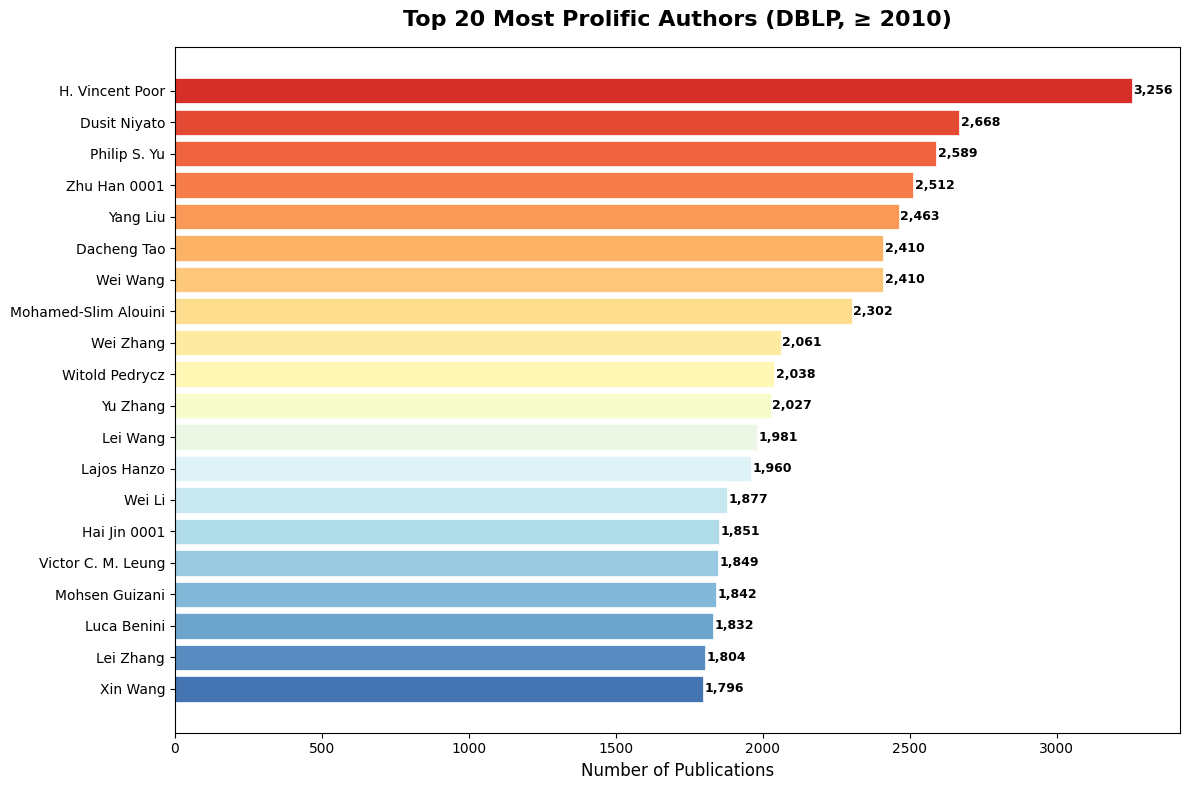

In [25]:
# Plot top 20 authors
top_n = 20
top_authors = author_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlBu(np.linspace(0.1, 0.9, top_n))
bars = ax.barh(range(top_n), top_authors.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_authors.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Number of Publications', fontsize=12)
ax.set_title(f'Top {top_n} Most Prolific Authors (DBLP, ≥ 2010)', fontsize=16, fontweight='bold', pad=15)

# Add count labels
for bar, count in zip(bars, top_authors.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'top_authors.png', dpi=150, bbox_inches='tight')
plt.show()

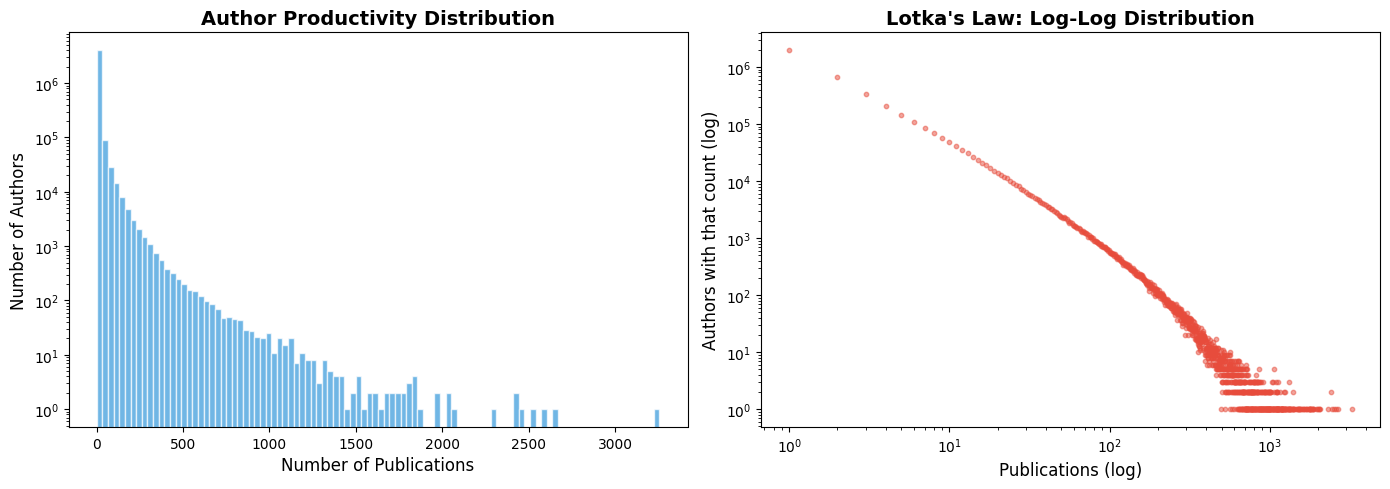


Productivity Distribution Insights:
Authors with only 1 paper: 46.8%
Top 1% of authors account for 26.8% of all publications
This follows a classic long-tail (power-law) distribution,
consistent with Lotka's Law of scientific productivity.


In [27]:
# Productivity distribution (Lotka's Law analysis)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of publication counts
counts = author_counts.values
ax1.hist(counts, bins=100, color='#3498db', alpha=0.7, edgecolor='white')
ax1.set_xlabel('Number of Publications', fontsize=12)
ax1.set_ylabel('Number of Authors', fontsize=12)
ax1.set_title('Author Productivity Distribution', fontsize=14, fontweight='bold')
ax1.set_yscale('log')

# Log-log plot (Lotka's Law)
from collections import Counter
freq_dist = Counter(counts)
x = sorted(freq_dist.keys())
y = [freq_dist[k] for k in x]

ax2.scatter(x, y, s=10, alpha=0.5, color='#e74c3c')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Publications (log)', fontsize=12)
ax2.set_ylabel('Authors with that count (log)', fontsize=12)
ax2.set_title("Lotka's Law: Log-Log Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'author_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Commentary
pct_single = (author_counts == 1).sum() / len(author_counts) * 100
pct_top1 = author_counts.head(int(len(author_counts)*0.01)).sum() / author_counts.sum() * 100
print(f"\nProductivity Distribution Insights:")
print(f"Authors with only 1 paper: {pct_single:.1f}%")
print(f"Top 1% of authors account for {pct_top1:.1f}% of all publications")
print(f"This follows a classic long-tail (power-law) distribution,")
print(f"consistent with Lotka's Law of scientific productivity.")

The DBLP dataset includes over 4.1 million unique authors, reflecting the vast and diverse community contributing to computer science research. A small group of highly prolific researchers stands out, with the most productive individuals publishing well over two thousand papers each. This highlights the presence of key contributors who have had a sustained and significant impact on the field.

At the same time, the distribution of productivity is highly uneven. Nearly half of all authors have only a single publication, indicating that many contributors participate only briefly in the literature. In contrast, the top 1 percent of authors are responsible for more than a quarter of all publications. This strong imbalance follows a classic long tail pattern consistent with Lotka’s Law, where a small fraction of researchers accounts for a disproportionately large share of scientific output.

Such a distribution suggests that while the field continues to attract a large number of new and occasional contributors, its overall direction and volume of output are heavily influenced by a relatively small core of highly active researchers. 

---
## 2.4 Co-Author Network (Basic)

Build a co-authorship graph and analyze basic network properties.

In [30]:
from src.network import build_coauthor_graph, get_top_subgraph, plot_network, degree_distribution
import networkx as nx
# Build co-author graph (min 2 co-authored papers to reduce noise)
G = build_coauthor_graph(df, min_papers=2)

print(f"\nNetwork Statistics:")
print(f"Nodes (authors): {G.number_of_nodes():,}")
print(f"Edges (co-authorships): {G.number_of_edges():,}")
print(f"Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.1f}")

# Connected components
components = list(nx.connected_components(G))
largest_cc = max(components, key=len)
print(f"Connected components: {len(components):,}")
print(f"Largest component: {len(largest_cc):,} nodes ({len(largest_cc)/G.number_of_nodes()*100:.1f}%)")

Co-author graph: 1,871,625 nodes, 9,743,735 edges

Network Statistics:
Nodes (authors): 1,871,625
Edges (co-authorships): 9,743,735
Average degree: 10.4
Connected components: 40,679
Largest component: 1,759,399 nodes (94.0%)


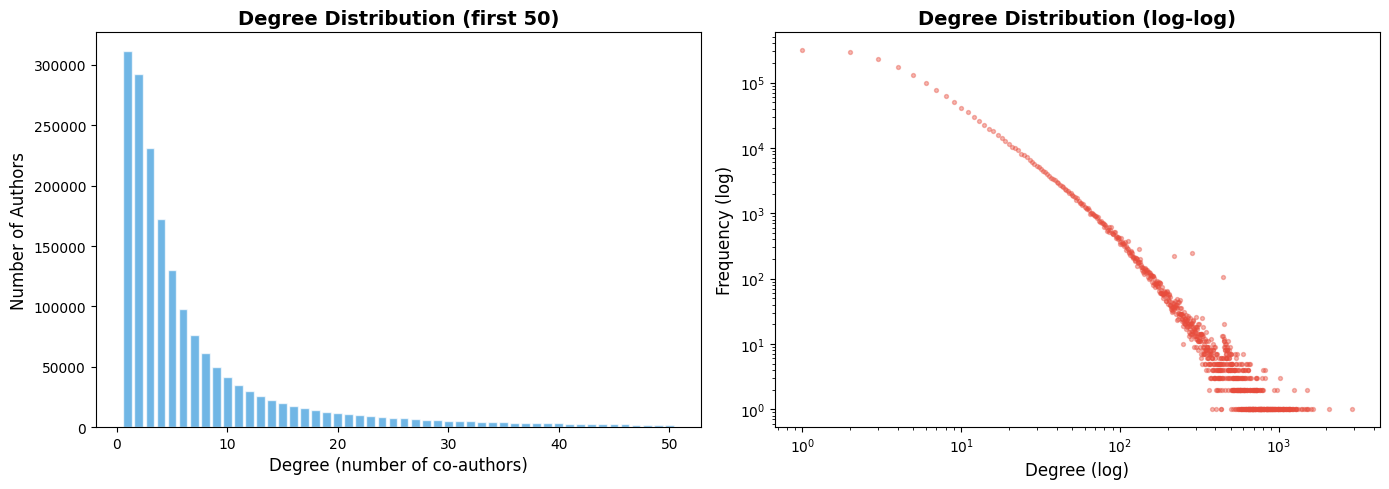

In [31]:
import networkx as nx

# Degree distribution
degrees, counts = degree_distribution(G)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(degrees[:50], counts[:50], color='#3498db', alpha=0.7, edgecolor='white')
ax1.set_xlabel('Degree (number of co-authors)', fontsize=12)
ax1.set_ylabel('Number of Authors', fontsize=12)
ax1.set_title('Degree Distribution (first 50)', fontsize=14, fontweight='bold')

ax2.scatter(degrees, counts, s=8, alpha=0.4, color='#e74c3c')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Degree (log)', fontsize=12)
ax2.set_ylabel('Frequency (log)', fontsize=12)
ax2.set_title('Degree Distribution (log-log)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Subgraph: 5000 nodes, 275526 edges


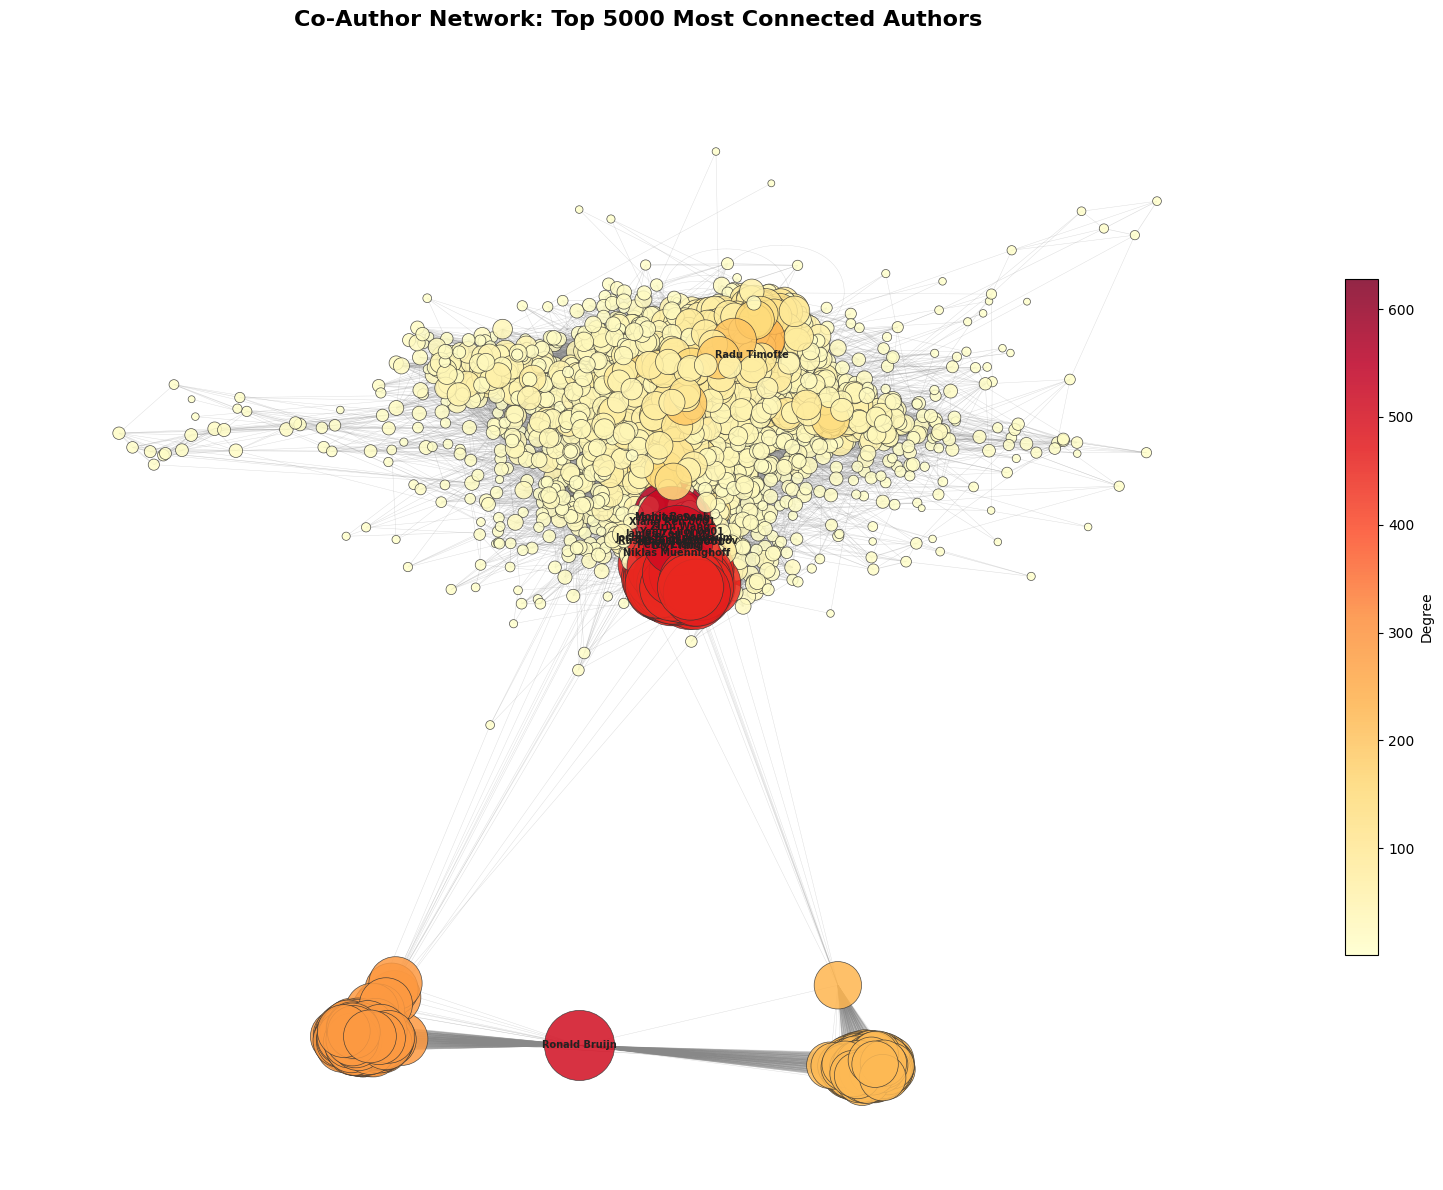

In [34]:
# Visualize subgraph of top 5000 most connected authors
sub_G = get_top_subgraph(G, top_n=5000)
print(f"Subgraph: {sub_G.number_of_nodes()} nodes, {sub_G.number_of_edges()} edges")

plot_network(
    sub_G, 
    title="Co-Author Network: Top 5000 Most Connected Authors",
    figsize=(16, 12),
    save_path=str(PROJECT_ROOT / 'data' / 'processed' / 'coauthor_network.png'),
)

The co-authorship network derived from the DBLP dataset comprises 1,871,625 author nodes and 9,743,735 collaboration edges, yielding an average degree of 10.4 co-authors per researcher. The network is organized into 40,679 connected components, though it is dominated by a single giant component containing 1,759,399 nodes, representing 94.0 percent of all authors. This high connectivity indicates that the computer science research community, despite its scale, forms a largely cohesive collaborative structure.

The visualization of the top 5,000 most connected authors reflects this structure clearly. The majority of highly connected researchers form a dense central cluster, with degree values concentrated in the 200 to 400 range as indicated by the orange coloring. A smaller group of authors in the deep red range exceeds 600 connections, positioning them as central hubs within the network. 

Radu Timofte is notably visible as a high-degree node slightly separated from the densest core, suggesting a bridging role across subfields. 

Ronald Bruijn appears as an isolated high-degree node at the periphery of the visualization, connected to two distinct local clusters but detached from the main component, which may reflect specialization in a niche subfield or a distinct regional research community.

Overall, the network exhibits properties consistent with a scale-free structure, where a small number of authors accumulate a disproportionately large number of collaborations while the majority maintain moderate connectivity. This pattern is characteristic of large academic collaboration networks and reinforces the observation that prolific researchers and large research groups serve as structural anchors within the broader community.

---
## 2.5 Most Common Keywords (from Titles)

What are the most frequently used terms in CS paper titles?

In [39]:
from src.preprocessing import get_top_keywords

# Filter to papers with titles
titles = df['title'].dropna().tolist()
print(f"Analyzing {len(titles):,} titles...")

# Top 30 unigrams
top_unigrams = get_top_keywords(titles, top_n=30, ngram=1)

# Top 20 bigrams
top_bigrams = get_top_keywords(titles, top_n=20, ngram=2)

print("\nTop 10 Unigrams:")
for word, count in top_unigrams[:10]:
    print(f"   {word:25s} {count:>10,}")

print("\nTop 10 Bigrams:")
for bigram, count in top_bigrams[:10]:
    print(f"   {bigram:35s} {count:>10,}")

Analyzing 8,462,457 titles...

Top 10 Unigrams:
   learning                     620,148
   data                         478,352
   networks                     432,591
   analysis                     414,488
   multi                        364,418
   network                      354,158
   detection                    315,266
   time                         299,488
   control                      291,838
   design                       266,839

Top 10 Bigrams:
   neural networks                         90,977
   neural network                          86,195
   real time                               84,581
   deep learning                           82,579
   machine learning                        79,261
   reinforcement learning                  59,092
   large scale                             45,564
   sensor networks                         43,896
   wireless sensor                         37,758
   multi agent                             34,513


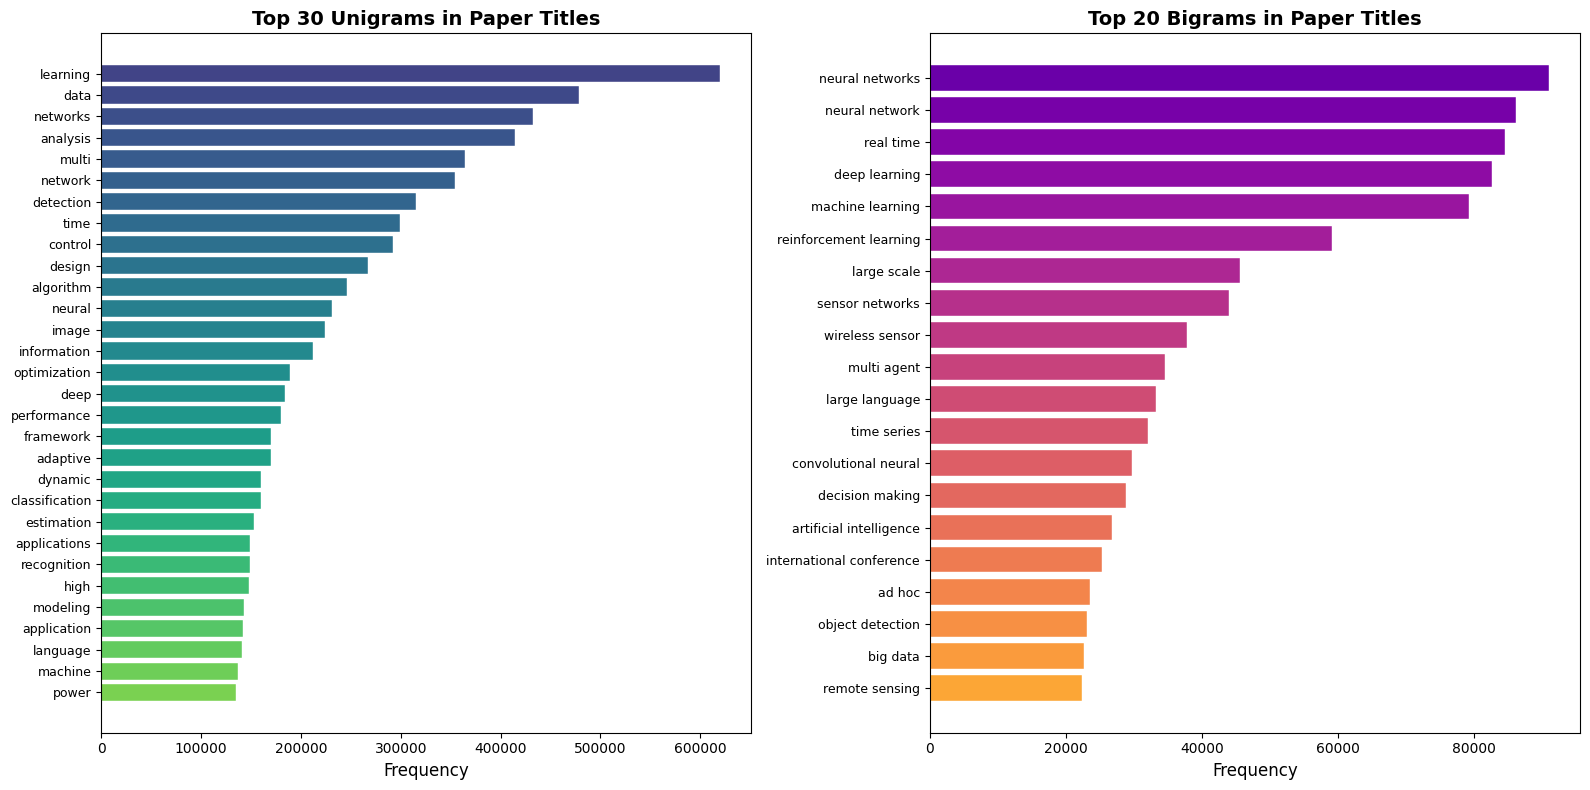

In [40]:
# Visualize top keywords
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Unigrams bar chart
words, counts_uni = zip(*top_unigrams)
colors1 = plt.cm.viridis(np.linspace(0.2, 0.8, len(words)))
ax1.barh(range(len(words)), counts_uni, color=colors1, edgecolor='white', linewidth=0.3)
ax1.set_yticks(range(len(words)))
ax1.set_yticklabels(words, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Frequency', fontsize=12)
ax1.set_title('Top 30 Unigrams in Paper Titles', fontsize=14, fontweight='bold')

# Bigrams bar chart
bigrams, counts_bi = zip(*top_bigrams)
colors2 = plt.cm.plasma(np.linspace(0.2, 0.8, len(bigrams)))
ax2.barh(range(len(bigrams)), counts_bi, color=colors2, edgecolor='white', linewidth=0.3)
ax2.set_yticks(range(len(bigrams)))
ax2.set_yticklabels(bigrams, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Frequency', fontsize=12)
ax2.set_title('Top 20 Bigrams in Paper Titles', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'keywords.png', dpi=150, bbox_inches='tight')
plt.show()

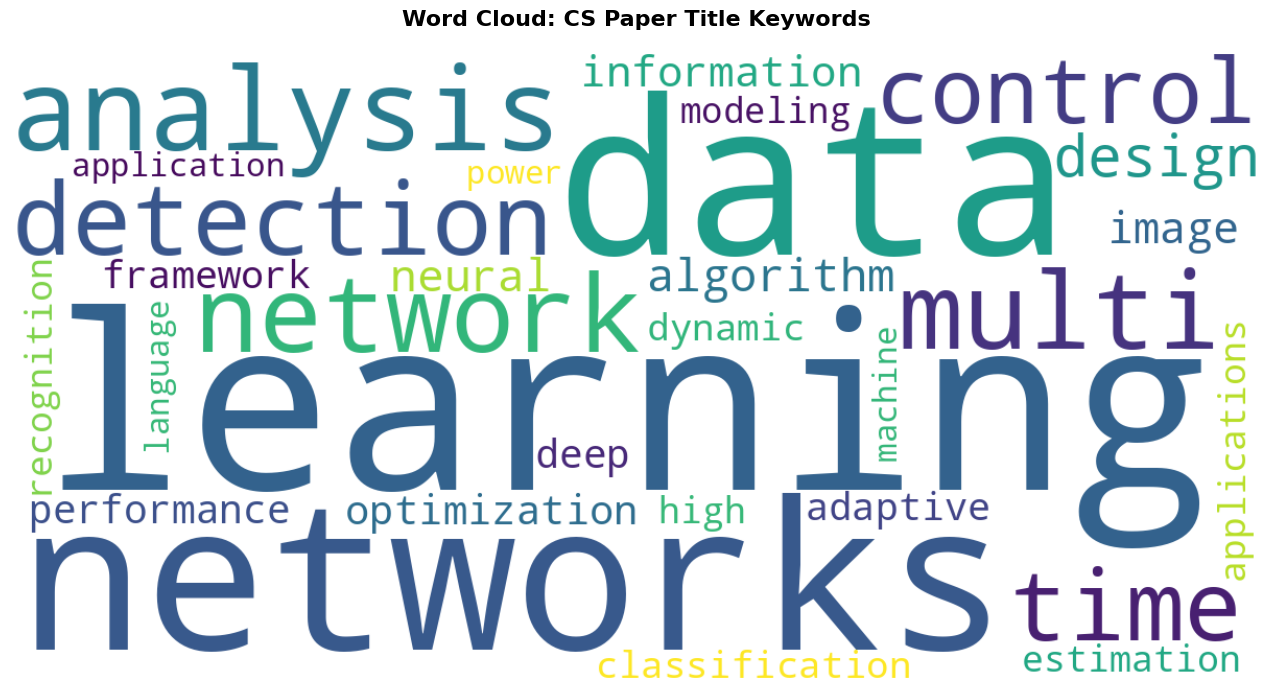

In [41]:
# Word Cloud
word_freq = dict(top_unigrams)

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=150,
    colormap='viridis',
    prefer_horizontal=0.7,
    min_font_size=8,
).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud: CS Paper Title Keywords', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

The analysis of over 8.4 million publication titles reveals clear thematic trends in computer science research. The most frequent unigrams are dominated by terms such as learning, data, networks, and analysis, reflecting the central role of data driven methods and interconnected systems across the field. The prominence of words like detection, control, and design also points to a strong emphasis on applied and engineering oriented research.

The most common bigrams further reinforce these patterns, with neural networks, deep learning, and machine learning appearing prominently. This highlights the significant influence of artificial intelligence and modern learning based approaches in recent years. At the same time, terms such as real time, large scale, and sensor networks indicate ongoing interest in scalable systems and real world applications. Overall, the vocabulary suggests a field that is increasingly shaped by data intensive methods and intelligent systems, while still maintaining strong foundations in systems and network oriented research.